# ASPI & S&P SL20: news sentiment prediction laboratory
Complete Anaconda/Jupyter workflow for **next-session Up / Down / Stable classification**.

**Start:** use Python 3.11 in a fresh Anaconda environment. Run the installation cell once, restart the kernel, then run from section 2 onward. Internet is required for packages and the first FinBERT download. CPU is supported; sentiment inference can take considerable time. Scores are cached.

**Results are produced when you run this notebook. No accuracy is pre-filled or guaranteed.** The original workbook is never modified. The latest 20% is a final holdout; tune using earlier data only. After seeing the final test, additional changes require a genuinely new test period.

Timing limitation: headline publication times and source availability are unverified. Default inputs are delayed by one trading session, a conservative assumption, **not proof of availability**. Results are historical research estimates, not a validated live trading simulation. Retrospective workbook corrections may also differ from data available at the time.


## 1. Install once, then restart the kernel
In Anaconda Prompt, you may first run `conda create -n cse-research python=3.11 -y`, then `conda activate cse-research`, then `pip install notebook`, then `jupyter notebook`.

In [2]:
%pip install "numpy>=1.26,<3" "pandas>=2.2,<3" "scikit-learn>=1.5,<1.8" "scipy>=1.12,<2" "matplotlib>=3.8,<4" "seaborn>=0.13,<1" "openpyxl>=3.1,<4" "torch>=2.6,<3" "transformers>=4.45,<5" "xgboost>=2.1,<4" "catboost>=1.2.7,<2" "tqdm>=4.66" "joblib>=1.3"

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached catboost-1.2.10-cp311-cp311-win_amd64.whl.metadata (1.5 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached gr

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 2. Configuration
Your Windows workbook path is already entered. Keep the target and final test definition fixed. `N_TRIALS=8` is a moderate search; increasing it increases runtime and validation-selection risk. No automatic search-until-70% loop is used.

In [20]:
from pathlib import Path
import os, re, json, hashlib, platform, importlib.metadata, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm
import joblib

DATA_PATH = Path(r"C:\Users\USER\OneDrive\Documents\RESEARCH METHODOLOGY\FINALS\2026 OCT 01\CSE_ASPI_SP_SL20_Corrected (1).xlsx")
OUTPUT_ROOT = DATA_PATH.parent / "CSE_Research_Outputs"
SEED = 42
TEST_FRACTION = 0.20
N_SPLITS = 4
GAP = 1                       # purge one row for the one-session future label
N_TRIALS = 8
FEATURE_DELAY = 1             # 0 only after verifying end-of-day availability
THRESHOLD_PCT = 0.1
FINBERT_MODEL = "ProsusAI/finbert"
FINBERT_REVISION = "main"      # resolved commit recorded below; cache keyed by it
BATCH_SIZE = 32
MAX_TOKENS = 128
LABELS = ["Down", "Stable", "Up"]
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
assert DATA_PATH.exists(), f"Workbook not found: {DATA_PATH}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = OUTPUT_ROOT / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir()
CACHE_DIR = OUTPUT_ROOT / "sentiment_cache"
CACHE_DIR.mkdir(exist_ok=True)
print("Outputs:", RUN_DIR)
print("Python:", platform.python_version())


Outputs: C:\Users\USER\OneDrive\Documents\RESEARCH METHODOLOGY\FINALS\2026 OCT 01\CSE_Research_Outputs\run_20261002_101508_699854
Python: 3.11.16


## 3. Audit the workbook and recalculate targets
Targets are recomputed from the next actual retained session. Missing news remains unknown. Market dates must already represent genuine sessions; arithmetic validation does not independently certify source values.

,missing,dtype
Trading_Date,0,datetime64[ns]
ASPI,0,float64
SP_SL20,0,float64
PDF_URL,0,object
Source_Method,0,object
Extraction_Status,0,object
Quality_Flag,0,object
News_Count,3,float64
Same_Date_News_Count,3,float64
Earlier_Date_Mapped_News_Count,3,float64


Rows: 735 Dates: 2023-04-03 00:00:00 to 2026-04-30 00:00:00


,ASPI,SP_SL20
Up,379,356
Down,268,293
Stable,87,85


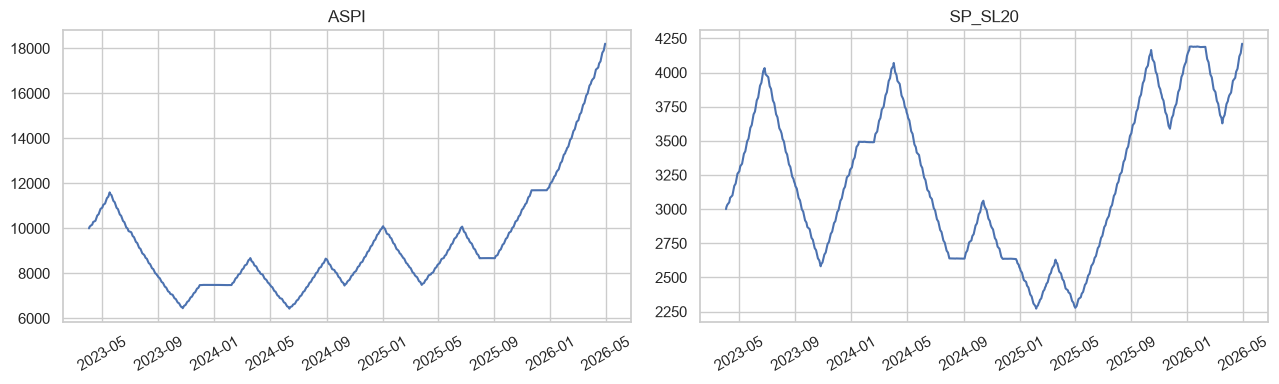

In [21]:
df = pd.read_excel(DATA_PATH, sheet_name="Corrected_Data")
df["Trading_Date"] = pd.to_datetime(df["Trading_Date"], errors="raise")
df = df.sort_values("Trading_Date").reset_index(drop=True)
assert not df.Trading_Date.duplicated().any(), "Duplicate dates require review."
assert len(df) > 200, "Too few rows for this validation design."
for index in ["ASPI", "SP_SL20"]:
    df[index] = pd.to_numeric(df[index], errors="raise")
    assert df[index].notna().all() and (df[index] > 0).all()
    ret = (df[index].shift(-1) / df[index] - 1) * 100
    supplied = pd.to_numeric(df[index + "_Next_Day_Return_Pct"], errors="coerce")
    mismatch = supplied.notna() & ret.notna() & ((supplied-ret).abs() > 0.00011)
    assert not mismatch.any(), f"Return mismatch for {index}; inspect workbook."
    df[index + "_target_return"] = ret
    target = pd.Series(np.select([ret < -THRESHOLD_PCT, ret > THRESHOLD_PCT], [0,2], default=1), index=df.index, dtype=float)
    target[ret.isna()] = np.nan
    df[index + "_y"] = target
    expected_labels = target.map(dict(enumerate(LABELS)))
    if index + "_Next_Day_Movement" in df:
        assert (expected_labels.fillna("MISSING") == df[index + "_Next_Day_Movement"].fillna("MISSING")).all(), "Label definition differs from workbook."
df["Target_Date"] = df.Trading_Date.shift(-1)
audit = pd.DataFrame({"missing":df.isna().sum(), "dtype":df.dtypes.astype(str)})
audit.to_csv(RUN_DIR / "data_audit.csv")
display(audit)
print("Rows:", len(df), "Dates:", df.Trading_Date.min(), "to", df.Trading_Date.max())
display(pd.DataFrame({k:df[k+"_y"].map(dict(enumerate(LABELS))).value_counts() for k in ["ASPI","SP_SL20"]}))
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, index in zip(axes, ["ASPI","SP_SL20"]):
    ax.plot(df.Trading_Date, df[index]); ax.set_title(index); ax.tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig(RUN_DIR/"market_history.png", dpi=160); plt.show()


## 4. Headline preparation and fixed relevance rule
Identical titles within a date are counted once for features. Identical titles on different dates remain separate observations. The keyword rule is a transparent heuristic, not a validated relevance classifier; review it before final testing. Both all-news and relevant-news statistics are retained.

In [22]:
headlines = df[["Trading_Date", "Headlines_Combined"]].copy()
headlines["Headline"] = headlines.Headlines_Combined.fillna("").str.split("|||", regex=False)
headlines = headlines.explode("Headline").drop(columns="Headlines_Combined")
headlines["Headline"] = headlines.Headline.str.replace(r"\s+", " ", regex=True).str.strip()
headlines = headlines.loc[headlines.Headline.ne("")].copy()
headlines["key"] = headlines.Headline.str.casefold()
headlines = headlines.drop_duplicates(["Trading_Date", "key"]).reset_index(drop=True)
RELEVANCE_PATTERN = r"\b(?:bank\w*|econom\w*|financ\w*|market\w*|stock\w*|share\w*|invest\w*|inflation|interest|rates?|rupee|dollar|currency|forex|imf|debt|bond\w*|tax\w*|budget|export\w*|import\w*|trade|touris\w*|earnings|profit\w*|revenue|dividend\w*|oil|fuel|energy|electricity|tariff\w*|gdp|cbsl|cse|monetary|fiscal|election\w*|policy|policies)\b"
headlines["relevant"] = headlines.Headline.str.contains(RELEVANCE_PATTERN, case=False, regex=True)
print("Headlines after within-date deduplication:", len(headlines))
print("Heuristic relevant fraction:", round(headlines.relevant.mean(),3))
display(headlines[["Trading_Date","Headline","relevant"]].sample(min(12,len(headlines)),random_state=SEED))


Headlines after within-date deduplication: 22244
Heuristic relevant fraction: 1.0


,Trading_Date,Headline,relevant
2740,2023-09-25,SYNTHETIC DEMO 115-3: Company profits fall sha...,True
14128,2025-06-13,SYNTHETIC DEMO 523-1: Company profits rise str...,True
14944,2025-07-11,SYNTHETIC DEMO 542-60: Company profits rise st...,True
13932,2025-06-04,SYNTHETIC DEMO 517-26: Company profits rise st...,True
11607,2025-02-28,SYNTHETIC DEMO 457-7: Company profits fall sha...,True
8497,2024-09-24,SYNTHETIC DEMO 354-3: Company profits fall sha...,True
5532,2024-03-13,SYNTHETIC DEMO 227-22: Company profits rise st...,True
9532,2024-11-18,SYNTHETIC DEMO 390-37: Company profits rise st...,True
2727,2023-09-22,SYNTHETIC DEMO 114-1: Company profits fall sha...,True
10432,2025-01-06,SYNTHETIC DEMO 423-38: Company profits fall sh...,True


## 5. FinBERT sentiment with resumable cache
This step downloads pretrained weights once. It scores individual headlines, not a whole day concatenated into a truncated input. Long headlines are truncated at 128 tokens. No substitute or synthetic sentiment is used if the download fails.

In [23]:
%pip install "torch>=2.6,<3" "transformers>=4.45,<5"

Note: you may need to restart the kernel to use updated packages.


In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("FinBERT device:", device)
tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL, revision=FINBERT_REVISION)
bert = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL, revision=FINBERT_REVISION).to(device).eval()
resolved_revision = getattr(bert.config, "_commit_hash", None) or FINBERT_REVISION
label_map = {int(k):str(v).lower() for k,v in bert.config.id2label.items()}
assert set(label_map.values()) == {"positive","negative","neutral"}, label_map
cache_tag = hashlib.sha256(f"{FINBERT_MODEL}|{resolved_revision}|{MAX_TOKENS}".encode()).hexdigest()[:16]
cache_file = CACHE_DIR / f"finbert_{cache_tag}.csv"
cache = pd.read_csv(cache_file) if cache_file.exists() else pd.DataFrame(columns=["Headline","positive","negative","neutral"])
known = set(cache.Headline)
todo = [s for s in headlines.Headline.unique() if s not in known]
new_rows = []
for start in tqdm(range(0,len(todo),BATCH_SIZE), desc="Scoring headlines"):
    batch = todo[start:start+BATCH_SIZE]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt").to(device)
    with torch.inference_mode():
        probs = torch.softmax(bert(**inputs).logits,dim=-1).cpu().numpy()
    for text, p in zip(batch,probs):
        new_rows.append({"Headline":text, **{label_map[j]:float(p[j]) for j in range(3)}})
    if len(new_rows) >= 1024 or start+BATCH_SIZE >= len(todo):
        cache = pd.concat([cache,pd.DataFrame(new_rows)],ignore_index=True).drop_duplicates("Headline")
        temp = cache_file.with_suffix(".tmp")
        cache.to_csv(temp,index=False); os.replace(temp,cache_file); new_rows=[]
scored = headlines.merge(cache,on="Headline",how="left",validate="many_to_one")
assert scored[["positive","negative","neutral"]].notna().all().all()
scored["sentiment"] = scored.positive-scored.negative
scored["positive_article"] = (scored[["positive","negative","neutral"]].idxmax(axis=1)=="positive").astype(int)
scored["negative_article"] = (scored[["positive","negative","neutral"]].idxmax(axis=1)=="negative").astype(int)
scored.to_csv(RUN_DIR/"headline_sentiment.csv",index=False)
display(scored[["Headline","positive","negative","neutral","sentiment"]].head(10))
del bert
if torch.cuda.is_available(): torch.cuda.empty_cache()


FinBERT device: cpu


Scoring headlines:   4%|▍         | 31/696 [00:45<16:51,  1.52s/it]C:\Users\USER\AppData\Local\Temp\ipykernel_31136\3208480558.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cache = pd.concat([cache,pd.DataFrame(new_rows)],ignore_index=True).drop_duplicates("Headline")
Scoring headlines: 100%|██████████| 696/696 [18:06<00:00,  1.56s/it]


,Headline,positive,negative,neutral,sentiment
0,SYNTHETIC DEMO 1-1: Company profits rise stron...,0.952076,0.021472,0.026451,0.930604
1,SYNTHETIC DEMO 1-2: Company profits rise stron...,0.953388,0.021081,0.025531,0.932308
2,SYNTHETIC DEMO 1-3: Company profits rise stron...,0.953426,0.021419,0.025156,0.932007
3,SYNTHETIC DEMO 1-4: Company profits rise stron...,0.953287,0.021554,0.025160,0.931733
4,SYNTHETIC DEMO 1-5: Company profits rise stron...,0.953035,0.021497,0.025468,0.931538
5,SYNTHETIC DEMO 1-6: Company profits rise stron...,0.953081,0.021569,0.025351,0.931512
6,SYNTHETIC DEMO 1-7: Company profits rise stron...,0.953028,0.022320,0.024651,0.930708
7,SYNTHETIC DEMO 1-8: Company profits rise stron...,0.953078,0.022036,0.024886,0.931042
8,SYNTHETIC DEMO 1-9: Company profits rise stron...,0.952946,0.022082,0.024972,0.930864
9,SYNTHETIC DEMO 1-10: Company profits rise stro...,0.953505,0.022025,0.024470,0.931481


## 6. Causal feature engineering
Rolling statistics use current/past observations only, then all features are shifted by `FEATURE_DELAY`. No future columns or audit labels enter model inputs. The first 21+delay rows are excluded to allow indicator warm-up. Imputation and scaling happen later inside each training fold.

In [25]:
daily = pd.DataFrame(index=pd.DatetimeIndex(df.Trading_Date))
for prefix, subset in [("all",scored),("relevant",scored[scored.relevant])]:
    agg = subset.groupby("Trading_Date").agg(sentiment=("sentiment","mean"), disagreement=("sentiment","std"), positive_share=("positive_article","mean"), negative_share=("negative_article","mean"), count=("Headline","size"))
    # One headline has zero within-day dispersion, not unknown dispersion.
    agg.loc[agg["count"].eq(1),"disagreement"] = 0.0
    daily = daily.join(agg.add_prefix(prefix+"_"))
known_news = pd.Series(df.Headlines_Combined.notna().to_numpy(),index=daily.index)
daily["news_missing"] = (~known_news).astype(float)
# A known bundle with no relevant titles has count zero, but undefined sentiment.
daily.loc[known_news,"relevant_count"] = daily.loc[known_news,"relevant_count"].fillna(0)
for prefix in ["all","relevant"]:
    daily[prefix+"_sentiment_change"] = daily[prefix+"_sentiment"].diff()
    for w in [3,5]:
        daily[f"{prefix}_sentiment_mean_{w}"] = daily[prefix+"_sentiment"].rolling(w,min_periods=w).mean()
news = daily.reset_index(drop=True)
market = pd.DataFrame(index=df.index)
for index in ["ASPI","SP_SL20"]:
    s=df[index]; r=s.pct_change(fill_method=None)
    for w in [1,3,5,10]: market[f"{index}_return_{w}"]=s.pct_change(w,fill_method=None)
    for lag in [1,2]: market[f"{index}_return_lag_{lag}"]=r.shift(lag)
    for w in [5,10,20]:
        market[f"{index}_vol_{w}"]=r.rolling(w).std()
        market[f"{index}_ma_distance_{w}"]=s/s.rolling(w).mean()-1
    delta=s.diff(); gain=delta.clip(lower=0).rolling(14).mean(); loss=(-delta.clip(upper=0)).rolling(14).mean()
    market[f"{index}_RSI14"]=100-100/(1+gain/loss.replace(0,np.nan))
    market.loc[loss.eq(0)&gain.gt(0),f"{index}_RSI14"]=100
    market.loc[loss.eq(0)&gain.eq(0),f"{index}_RSI14"]=50
features = pd.concat([market,news],axis=1).shift(FEATURE_DELAY).replace([np.inf,-np.inf],np.nan)
feature_sets = {"market":list(market.columns),"news":list(news.columns),"combined":list(features.columns)}
assert not any("Next_" in c or "_y" in c or "target" in c.lower() for c in features)
eligible = (df.index >= 21+FEATURE_DELAY) & df.ASPI_y.notna() & df.SP_SL20_y.notna()
X = features.loc[eligible].reset_index(drop=True)
meta = df.loc[eligible,["Trading_Date","Target_Date","ASPI_y","SP_SL20_y"]].reset_index(drop=True)
split = int(len(X)*(1-TEST_FRACTION))
train_idx = np.arange(split-GAP)
test_idx = np.arange(split,len(X))
assert meta.Target_Date.iloc[train_idx[-1]] < meta.Trading_Date.iloc[test_idx[0]]
features_out = pd.concat([meta,X],axis=1)
features_out.to_csv(RUN_DIR/"daily_features_and_targets.csv",index=False)
print("Training:",len(train_idx),"Purged:",GAP,"Final test:",len(test_idx))
print("Train dates:",meta.Trading_Date.iloc[train_idx[[0,-1]]].tolist())
print("Test dates:",meta.Trading_Date.iloc[test_idx[[0,-1]]].tolist())
display(X.head())


Training: 568 Purged: 1 Final test: 143
Train dates: [Timestamp('2023-05-11 00:00:00'), Timestamp('2025-09-19 00:00:00')]
Test dates: [Timestamp('2025-09-23 00:00:00'), Timestamp('2026-04-29 00:00:00')]


,ASPI_return_1,ASPI_return_3,ASPI_return_5,ASPI_return_10,ASPI_return_lag_1,ASPI_return_lag_2,ASPI_vol_5,ASPI_ma_distance_5,ASPI_vol_10,ASPI_ma_distance_10,...,relevant_positive_share,relevant_negative_share,relevant_count,news_missing,all_sentiment_change,all_sentiment_mean_3,all_sentiment_mean_5,relevant_sentiment_change,relevant_sentiment_mean_3,relevant_sentiment_mean_5
0,0.005278,0.016160,0.027182,0.055801,0.005314,0.005482,0.000082,0.010687,0.000183,0.024553,...,1.0,0.0,13.0,0.0,-0.001283,0.929261,0.929438,-0.001283,0.929261,0.929438
1,0.005485,0.016163,0.027274,0.056073,0.005278,0.005314,0.000096,0.010777,0.000166,0.024569,...,1.0,0.0,34.0,0.0,0.001071,0.929032,0.929301,0.001071,0.929032,0.929301
2,0.005336,0.016186,0.027186,0.056119,0.005485,0.005278,0.000098,0.010734,0.000161,0.024429,...,1.0,0.0,13.0,0.0,0.000307,0.929064,0.929345,0.000307,0.929064,0.929345
3,0.005602,0.016514,0.027309,0.056110,0.005336,0.005485,0.000136,0.010933,0.000161,0.024561,...,1.0,0.0,60.0,0.0,0.000307,0.929626,0.929331,0.000307,0.929626,0.929331
4,0.005462,0.016490,0.027460,0.055916,0.005602,0.005336,0.000128,0.010962,0.000149,0.024568,...,1.0,0.0,34.0,0.0,-0.000422,0.929690,0.929327,-0.000422,0.929690,0.929327


## 7. Models, search spaces and expanding-window validation
Five model families × three feature groups × two indices. Hyperparameters maximise mean validation accuracy; macro-F1 is also recorded. CV values are tuning scores and can be optimistic after selection. The final holdout is the independent evaluation. No final-test early stopping is used.

In [27]:
import json
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    make_scorer,
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ---------------------------------------------------------
# 1. Validate existing inputs from Sections 2–6
# ---------------------------------------------------------

train_idx = np.asarray(train_idx, dtype=int)

assert len(X) == len(meta), "X and meta must have matching rows."
assert len(train_idx) > 0, "Training indices are empty."
assert np.all(np.diff(train_idx) > 0), (
    "Training indices must be unique and chronologically ordered."
)
assert N_SPLITS >= 2, "N_SPLITS must be at least 2."
assert GAP >= 1, "Keep a gap of at least 1 for next-session targets."

RUN_DIR.mkdir(parents=True, exist_ok=True)

INDEX_NAMES = ["ASPI", "SP_SL20"]
CLASS_IDS = [0, 1, 2]
CLASS_NAMES = ["Down", "Stable", "Up"]

MIN_PER_CLASS = 5
MIN_VALIDATION_ROWS = 20

development_targets = {}

for index_name in INDEX_NAMES:
    values = meta[index_name + "_y"].iloc[train_idx]

    assert values.notna().all(), (
        f"{index_name}: missing training targets."
    )
    assert values.isin(CLASS_IDS).all(), (
        f"{index_name}: targets must be 0, 1 or 2."
    )

    development_targets[index_name] = (
        values.astype(int).reset_index(drop=True)
    )


# ---------------------------------------------------------
# 2. Find an initial window containing all three classes
#    Uses development data only, never final-test labels.
# ---------------------------------------------------------

n_train = len(train_idx)
minimum_training_size = None

for size in range(60, n_train + 1):
    enough_classes = True

    for index_name in INDEX_NAMES:
        counts = (
            development_targets[index_name]
            .iloc[:size]
            .value_counts()
            .reindex(CLASS_IDS, fill_value=0)
        )

        if (counts < MIN_PER_CLASS).any():
            enough_classes = False
            break

    if enough_classes:
        minimum_training_size = size
        break

if minimum_training_size is None:
    raise ValueError(
        "The development data does not contain at least "
        f"{MIN_PER_CLASS} examples of every class for both indices."
    )

validation_size = (
    n_train - minimum_training_size - GAP
) // N_SPLITS

if validation_size < MIN_VALIDATION_ROWS:
    raise ValueError(
        f"Only {validation_size} validation rows per fold remain. "
        "Reduce N_SPLITS in the configuration and rerun this cell. "
        "Do not change the final test set."
    )

cv = list(
    TimeSeriesSplit(
        n_splits=N_SPLITS,
        test_size=validation_size,
        gap=GAP,
    ).split(np.arange(n_train))
)


# ---------------------------------------------------------
# 3. Verify folds and save their dates/class counts
# ---------------------------------------------------------

fold_rows = []

for fold_number, (tr, va) in enumerate(cv, start=1):
    last_training_target_date = pd.Timestamp(
        meta.Target_Date.iloc[train_idx[tr[-1]]]
    )
    first_validation_date = pd.Timestamp(
        meta.Trading_Date.iloc[train_idx[va[0]]]
    )

    assert last_training_target_date < first_validation_date, (
        f"Fold {fold_number}: training targets overlap validation dates."
    )

    print(
        f"\nFold {fold_number}: "
        f"{len(tr)} training rows | {len(va)} validation rows"
    )

    for index_name in INDEX_NAMES:
        y_dev = development_targets[index_name]

        train_counts = (
            y_dev.iloc[tr]
            .value_counts()
            .reindex(CLASS_IDS, fill_value=0)
        )
        validation_counts = (
            y_dev.iloc[va]
            .value_counts()
            .reindex(CLASS_IDS, fill_value=0)
        )

        assert (train_counts >= MIN_PER_CLASS).all(), (
            f"{index_name}, fold {fold_number}: "
            "insufficient training examples for a class."
        )

        print(
            f"  {index_name} training: "
            f"Down={train_counts[0]}, "
            f"Stable={train_counts[1]}, "
            f"Up={train_counts[2]}"
        )

        fold_rows.append({
            "index": index_name,
            "fold": fold_number,
            "training_rows": len(tr),
            "validation_rows": len(va),
            "training_start": meta.Trading_Date.iloc[train_idx[tr[0]]],
            "training_end": meta.Trading_Date.iloc[train_idx[tr[-1]]],
            "validation_start": meta.Trading_Date.iloc[train_idx[va[0]]],
            "validation_end": meta.Trading_Date.iloc[train_idx[va[-1]]],
            **{
                f"train_{label}": int(train_counts[class_id])
                for class_id, label in zip(CLASS_IDS, CLASS_NAMES)
            },
            **{
                f"validation_{label}": int(validation_counts[class_id])
                for class_id, label in zip(CLASS_IDS, CLASS_NAMES)
            },
        })

fold_details = pd.DataFrame(fold_rows)
fold_details.to_csv(
    RUN_DIR / "validation_fold_details.csv",
    index=False,
)

print("\nChronological validation folds are ready.")


# ---------------------------------------------------------
# 4. Candidate models and search spaces
# ---------------------------------------------------------

def candidates():
    return {
        "LogisticRegression": (
            LogisticRegression(
                max_iter=3000,
                random_state=SEED,
            ),
            {
                "model__C": [0.01, 0.1, 1, 10],
                "model__class_weight": [None, "balanced"],
            },
        ),

        "RandomForest": (
            RandomForestClassifier(
                n_estimators=300,
                n_jobs=1,
                random_state=SEED,
            ),
            {
                "model__max_depth": [3, 5, 8, None],
                "model__min_samples_leaf": [5, 10, 20],
                "model__max_features": ["sqrt", 0.8],
                "model__class_weight": [None, "balanced"],
            },
        ),

        "ExtraTrees": (
            ExtraTreesClassifier(
                n_estimators=300,
                n_jobs=1,
                random_state=SEED,
            ),
            {
                "model__max_depth": [3, 5, 8, None],
                "model__min_samples_leaf": [5, 10, 20],
                "model__max_features": ["sqrt", 0.8],
                "model__class_weight": [None, "balanced"],
            },
        ),

        "XGBoost": (
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                tree_method="hist",
                n_jobs=1,
                random_state=SEED,
            ),
            {
                "model__n_estimators": [150, 300],
                "model__max_depth": [2, 3, 4],
                "model__learning_rate": [0.02, 0.05, 0.1],
                "model__min_child_weight": [5, 10],
                "model__subsample": [0.7, 1.0],
                "model__colsample_bytree": [0.7, 1.0],
                "model__reg_lambda": [3, 10],
            },
        ),

        "CatBoost": (
            CatBoostClassifier(
                loss_function="MultiClass",
                verbose=False,
                allow_writing_files=False,
                thread_count=1,
                random_seed=SEED,
            ),
            {
                "model__iterations": [150, 300],
                "model__depth": [3, 4, 5],
                "model__learning_rate": [0.02, 0.05, 0.1],
                "model__l2_leaf_reg": [3, 10, 20],
            },
        ),
    }


def pipeline(model):
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
        ),
        ("scale", StandardScaler()),
        ("model", model),
    ])


def aligned_proba(model, values):
    """Return probabilities in fixed Down, Stable, Up order."""
    raw = np.asarray(model.predict_proba(values), dtype=float)
    classes = np.asarray(model.classes_).reshape(-1).astype(int)

    out = np.zeros((len(values), 3), dtype=float)

    for position, class_id in enumerate(classes):
        out[:, class_id] = raw[:, position]

    assert np.isfinite(out).all(), "Non-finite probabilities found."
    assert np.allclose(out.sum(axis=1), 1.0, atol=1e-5), (
        "Predicted probabilities do not sum to 1."
    )

    return out


# Count all three classes consistently, even when a validation
# window happens to contain no examples of one class.
macro_f1_scorer = make_scorer(
    f1_score,
    labels=CLASS_IDS,
    average="macro",
    zero_division=0,
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": macro_f1_scorer,
}


# ---------------------------------------------------------
# 5. Tune using development folds only
# ---------------------------------------------------------

search_rows = []
fitted = {}
tuning_oof = {}

total_experiments = (
    len(INDEX_NAMES) * len(feature_sets) * len(candidates())
)
experiment_number = 0

for index in INDEX_NAMES:
    y_dev = development_targets[index]

    for group, cols in feature_sets.items():
        X_dev = X.iloc[train_idx][cols].reset_index(drop=True)

        for name, (estimator, params) in candidates().items():
            experiment_number += 1

            print(
                f"\n[{experiment_number}/{total_experiments}] "
                f"{index} | {group} | {name}",
                flush=True,
            )

            # Avoid asking for more trials than the finite space.
            possible_combinations = int(
                np.prod([len(values) for values in params.values()])
            )
            trials = min(int(N_TRIALS), possible_combinations)

            search = RandomizedSearchCV(
                estimator=pipeline(estimator),
                param_distributions=params,
                n_iter=trials,
                scoring=scoring,
                refit="accuracy",
                cv=cv,
                n_jobs=1,
                random_state=SEED,
                error_score="raise",
                return_train_score=True,
            )

            search.fit(X_dev, y_dev)

            key = (index, group, name)
            fitted[key] = search.best_estimator_

            result = pd.DataFrame(search.cv_results_)
            result.to_csv(
                RUN_DIR / f"search_{index}_{group}_{name}.csv",
                index=False,
            )

            best = search.best_index_
            train_accuracy = accuracy_score(
                y_dev,
                search.predict(X_dev),
            )

            search_rows.append({
                "index": index,
                "features": group,
                "model": name,
                "cv_accuracy": float(search.best_score_),
                "cv_accuracy_sd": float(
                    result.loc[best, "std_test_accuracy"]
                ),
                "cv_macro_f1": float(
                    result.loc[best, "mean_test_macro_f1"]
                ),
                "train_accuracy": float(train_accuracy),
                "parameters": json.dumps(search.best_params_),
            })

            print(
                f"  Training accuracy: {train_accuracy:.2%}\n"
                f"  Mean validation accuracy: {search.best_score_:.2%}",
                flush=True,
            )

            # Generate tuning-fold probabilities for Section 8.
            # These are development predictions, not final-test results.
            oof = np.full((len(train_idx), 3), np.nan)

            for tr, va in cv:
                fold_model = clone(search.best_estimator_)

                fold_model.fit(
                    X_dev.iloc[tr],
                    y_dev.iloc[tr],
                )

                oof[va] = aligned_proba(
                    fold_model,
                    X_dev.iloc[va],
                )

            tuning_oof[key] = oof

            # Save progress after each completed model.
            pd.DataFrame(search_rows).to_csv(
                RUN_DIR / "validation_model_comparison.csv",
                index=False,
            )


# ---------------------------------------------------------
# 6. Show validation results
# ---------------------------------------------------------

cv_results = pd.DataFrame(search_rows)

cv_results.to_csv(
    RUN_DIR / "validation_model_comparison.csv",
    index=False,
)

display(
    cv_results.sort_values(
        ["index", "cv_accuracy"],
        ascending=[True, False],
    ).style.format({
        "cv_accuracy": "{:.2%}",
        "cv_accuracy_sd": "{:.2%}",
        "cv_macro_f1": "{:.2%}",
        "train_accuracy": "{:.2%}",
    })
)

print("\nSection 7 completed.")
print("Continue with Sections 8–11 for final-test results.")
print("Saved to:", RUN_DIR)
print(
    "For the dummy workbook, all reported performance "
    "is SYNTHETIC DEMONSTRATION performance."
)



Fold 1: 175 training rows | 98 validation rows
  ASPI training: Down=106, Stable=37, Up=32
  SP_SL20 training: Down=81, Stable=7, Up=87

Fold 2: 273 training rows | 98 validation rows
  ASPI training: Down=160, Stable=43, Up=70
  SP_SL20 training: Down=137, Stable=21, Up=115

Fold 3: 371 training rows | 98 validation rows
  ASPI training: Down=187, Stable=43, Up=141
  SP_SL20 training: Down=186, Stable=43, Up=142

Fold 4: 469 training rows | 98 validation rows
  ASPI training: Down=241, Stable=43, Up=185
  SP_SL20 training: Down=236, Stable=64, Up=169

Chronological validation folds are ready.

[1/30] ASPI | market | LogisticRegression
  Training accuracy: 93.66%
  Mean validation accuracy: 90.56%

[2/30] ASPI | market | RandomForest
  Training accuracy: 95.42%
  Mean validation accuracy: 94.90%

[3/30] ASPI | market | ExtraTrees
  Training accuracy: 95.42%
  Mean validation accuracy: 94.90%

[4/30] ASPI | market | XGBoost
  Training accuracy: 95.77%
  Mean validation accuracy: 94.90%

,index,features,model,cv_accuracy,cv_accuracy_sd,cv_macro_f1,train_accuracy,parameters
10,ASPI,combined,LogisticRegression,95.15%,1.11%,77.00%,96.30%,"{""model__class_weight"": null, ""model__C"": 0.1}"
1,ASPI,market,RandomForest,94.90%,1.02%,77.72%,95.42%,"{""model__min_samples_leaf"": 5, ""model__max_features"": 0.8, ""model__max_depth"": 3, ""model__class_weight"": ""balanced""}"
2,ASPI,market,ExtraTrees,94.90%,1.02%,77.72%,95.42%,"{""model__min_samples_leaf"": 5, ""model__max_features"": 0.8, ""model__max_depth"": 3, ""model__class_weight"": ""balanced""}"
3,ASPI,market,XGBoost,94.90%,1.02%,77.72%,95.77%,"{""model__subsample"": 0.7, ""model__reg_lambda"": 10, ""model__n_estimators"": 150, ""model__min_child_weight"": 10, ""model__max_depth"": 4, ""model__learning_rate"": 0.02, ""model__colsample_bytree"": 0.7}"
12,ASPI,combined,ExtraTrees,94.64%,1.33%,77.13%,96.13%,"{""model__min_samples_leaf"": 5, ""model__max_features"": 0.8, ""model__max_depth"": 3, ""model__class_weight"": ""balanced""}"
4,ASPI,market,CatBoost,94.13%,1.33%,76.70%,95.95%,"{""model__learning_rate"": 0.05, ""model__l2_leaf_reg"": 10, ""model__iterations"": 300, ""model__depth"": 5}"
13,ASPI,combined,XGBoost,93.88%,2.16%,76.54%,97.01%,"{""model__subsample"": 0.7, ""model__reg_lambda"": 3, ""model__n_estimators"": 300, ""model__min_child_weight"": 10, ""model__max_depth"": 3, ""model__learning_rate"": 0.02, ""model__colsample_bytree"": 1.0}"
11,ASPI,combined,RandomForest,93.11%,3.78%,74.25%,95.95%,"{""model__min_samples_leaf"": 5, ""model__max_features"": 0.8, ""model__max_depth"": 3, ""model__class_weight"": ""balanced""}"
14,ASPI,combined,CatBoost,92.09%,5.51%,74.15%,97.18%,"{""model__learning_rate"": 0.05, ""model__l2_leaf_reg"": 3, ""model__iterations"": 150, ""model__depth"": 4}"
0,ASPI,market,LogisticRegression,90.56%,3.84%,68.51%,93.66%,"{""model__class_weight"": null, ""model__C"": 0.1}"



Section 7 completed.
Continue with Sections 8–11 for final-test results.
Saved to: C:\Users\USER\OneDrive\Documents\RESEARCH METHODOLOGY\FINALS\2026 OCT 01\CSE_Research_Outputs\run_20261002_101508_699854
For the dummy workbook, all reported performance is SYNTHETIC DEMONSTRATION performance.


## 8. Select models and ensemble BEFORE opening final-test results
The ensemble averages the top three combined-input models equally. Members are chosen by validation results. Its tuning-fold score is not an unbiased performance estimate. The selected winner is frozen now; later test tables are diagnostic comparisons, not a new model-selection round.

In [28]:
ensembles={}; selections={}; selection_scores=[]
for index in ["ASPI","SP_SL20"]:
    table=cv_results[cv_results["index"].eq(index)].sort_values("cv_accuracy",ascending=False)
    combined=table[table.features.eq("combined")].head(3)
    members=[(index,"combined",name) for name in combined.model]
    ensembles[index]=members
    p=np.mean([tuning_oof[k] for k in members],axis=0)
    valid=np.isfinite(p).all(axis=1)
    # Equal fold weighting matches RandomizedSearchCV's mean fold accuracy.
    fold_acc=[accuracy_score(meta[index+"_y"].iloc[train_idx[va]],p[va].argmax(axis=1)) for _,va in cv]
    ensemble_score=float(np.mean(fold_acc))
    winner=table.iloc[0]
    selected=(index,winner.features,winner.model)
    if ensemble_score > winner.cv_accuracy: selected=(index,"combined","SoftVoting")
    selections[index]=selected
    selection_scores.append({"index":index,"selected_features":selected[1],"selected_model":selected[2],"selection_cv_accuracy":max(float(winner.cv_accuracy),ensemble_score),"ensemble_cv_accuracy":ensemble_score})
selection_table=pd.DataFrame(selection_scores)
manifest={"input_sha256":hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),"seed":SEED,"threshold_pct":THRESHOLD_PCT,"feature_delay":FEATURE_DELAY,"gap":GAP,"n_splits":N_SPLITS,"n_trials":N_TRIALS,"test_start":str(meta.Trading_Date.iloc[test_idx[0]]),"test_end":str(meta.Trading_Date.iloc[test_idx[-1]]),"selected":selections,"ensemble_members":ensembles,"finbert_model":FINBERT_MODEL,"finbert_revision":resolved_revision,"relevance_pattern":RELEVANCE_PATTERN,"features":feature_sets,"versions":{p:importlib.metadata.version(p) for p in ["numpy","pandas","scikit-learn","torch","transformers","xgboost","catboost"]},"timing_limitation":"Publication and market source availability unverified; delayed-input research experiment."}
(RUN_DIR/"frozen_experiment_manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")
selection_table.to_csv(RUN_DIR/"selected_before_test.csv",index=False)
display(selection_table)
print("Selections frozen. Do not alter them based on final-test accuracy.")


,index,selected_features,selected_model,selection_cv_accuracy,ensemble_cv_accuracy
0,ASPI,combined,SoftVoting,0.954082,0.954082
1,SP_SL20,market,ExtraTrees,0.943878,0.915816


Selections frozen. Do not alter them based on final-test accuracy.


## 9. Final test: all accuracies, predictions and classification reports
Models remain fixed throughout the final test; each date uses the historical inputs then available under the stated delay assumption. This is daily one-step testing, not a single multi-month forecast. Baselines are training-majority and previous observed movement. Each model has saved class probabilities and predictions.

In [29]:
test_rows=[]; test_probs={}; test_predictions={}
def evaluate(index,group,name,pred,probs=None):
    actual=meta[index+"_y"].iloc[test_idx].astype(int).to_numpy()
    row={"index":index,"features":group,"model":name,"test_n":len(actual),"accuracy":accuracy_score(actual,pred),"balanced_accuracy":balanced_accuracy_score(actual,pred),"macro_f1":f1_score(actual,pred,labels=[0,1,2],average="macro",zero_division=0),"weighted_f1":f1_score(actual,pred,labels=[0,1,2],average="weighted",zero_division=0),"selected_before_test":selections[index]==(index,group,name)}
    if probs is not None:
        row["log_loss"]=log_loss(actual,probs,labels=[0,1,2])
        row["macro_ovr_auc"]=roc_auc_score(actual,probs,multi_class="ovr",average="macro",labels=[0,1,2]) if len(set(actual))==3 else np.nan
        test_probs[(index,group,name)]=probs
    test_rows.append(row); test_predictions[(index,group,name)]=np.asarray(pred)
    report=classification_report(actual,pred,labels=[0,1,2],target_names=LABELS,output_dict=True,zero_division=0)
    pd.DataFrame(report).T.to_csv(RUN_DIR/f"report_{index}_{group}_{name}.csv")
    output=meta.iloc[test_idx][["Trading_Date","Target_Date"]].copy()
    output["actual"]=[LABELS[v] for v in actual]; output["prediction"]=[LABELS[int(v)] for v in pred]
    output["correct"]=actual==pred
    if probs is not None:
        for j,label in enumerate(LABELS): output["prob_"+label]=probs[:,j]
    output.to_csv(RUN_DIR/f"predictions_{index}_{group}_{name}.csv",index=False)

for index in ["ASPI","SP_SL20"]:
    y=meta[index+"_y"].astype(int)
    majority=int(y.iloc[train_idx].mode().iloc[0])
    evaluate(index,"baseline","TrainingMajority",np.repeat(majority,len(test_idx)))
    # Use only the movement observed by the delayed input session.
    observed_return=df[index].pct_change(fill_method=None).shift(FEATURE_DELAY)*100
    persistence=np.select([observed_return < -THRESHOLD_PCT,observed_return > THRESHOLD_PCT],[0,2],default=1)
    persistence=pd.Series(persistence).loc[eligible].reset_index(drop=True).iloc[test_idx].to_numpy()
    evaluate(index,"baseline","Persistence",persistence)
    for key,m in fitted.items():
        if key[0]!=index: continue
        cols=feature_sets[key[1]]
        p=aligned_proba(m,X.iloc[test_idx][cols])
        evaluate(*key,p.argmax(axis=1),p)
    p=np.mean([test_probs[k] for k in ensembles[index]],axis=0)
    evaluate(index,"combined","SoftVoting",p.argmax(axis=1),p)
results=pd.DataFrame(test_rows)
results.to_csv(RUN_DIR/"ALL_TEST_ACCURACIES.csv",index=False)
shown=results.copy()
for c in ["accuracy","balanced_accuracy","macro_f1","weighted_f1"]: shown[c]=(shown[c]*100).round(2)
display(shown.sort_values(["index","features","model"]))
selected_results=results[results.selected_before_test].copy()
selected_results["above_70_percent"]=selected_results.accuracy > 0.70
selected_results.to_csv(RUN_DIR/"FINAL_SELECTED_RESULTS.csv",index=False)
print("PRIMARY RESULTS — winners selected before test:")
display(selected_results)


C:\Users\USER\conda-envs\cse-research\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\USER\conda-envs\cse-research\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\USER\conda-envs\cse-research\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\USER\conda-envs\cse-research\Lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\USER\conda-envs\cse-research\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes 

,index,features,model,test_n,accuracy,balanced_accuracy,macro_f1,weighted_f1,selected_before_test,log_loss,macro_ovr_auc
1,ASPI,baseline,Persistence,143,97.20,94.63,63.09,97.20,False,NaN,NaN
0,ASPI,baseline,TrainingMajority,143,0.00,0.00,0.00,0.00,False,NaN,NaN
16,ASPI,combined,CatBoost,143,95.10,89.67,60.94,95.36,False,0.190826,NaN
14,ASPI,combined,ExtraTrees,143,96.50,94.21,62.94,96.85,False,0.177633,NaN
12,ASPI,combined,LogisticRegression,143,81.82,57.64,39.39,80.21,False,0.565287,NaN
13,ASPI,combined,RandomForest,143,97.20,94.63,63.09,97.20,False,0.154606,NaN
17,ASPI,combined,SoftVoting,143,95.10,89.67,60.94,95.36,True,0.237029,NaN
15,ASPI,combined,XGBoost,143,95.80,90.08,61.22,96.06,False,0.214641,NaN
6,ASPI,market,CatBoost,143,95.80,90.08,61.09,95.72,False,0.216071,NaN
4,ASPI,market,ExtraTrees,143,97.20,94.63,63.09,97.20,False,0.200290,NaN


PRIMARY RESULTS — winners selected before test:


,index,features,model,test_n,accuracy,balanced_accuracy,macro_f1,weighted_f1,selected_before_test,log_loss,macro_ovr_auc,above_70_percent
17,ASPI,combined,SoftVoting,143,0.951049,0.896694,0.609445,0.953647,True,0.237029,NaN,True
22,SP_SL20,market,ExtraTrees,143,0.930070,0.923773,0.923773,0.930070,True,0.426302,0.933594,True


## 10. Plots, uncertainty and explanations
Block bootstrap intervals resample runs of five consecutive test observations to partly account for serial dependence. They are approximate, not guarantees. Permutation importance uses a held-out development fold and is diagnostic only; do not select new features using final-test results.

ASPI ('ASPI', 'combined', 'SoftVoting') Accuracy: 95.1 % Approx. 95% interval: [89.51 99.3 ]
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00         0
      Stable       0.90      0.82      0.86        22
          Up       0.97      0.98      0.97       121

    accuracy                           0.95       143
   macro avg       0.62      0.60      0.61       143
weighted avg       0.96      0.95      0.95       143



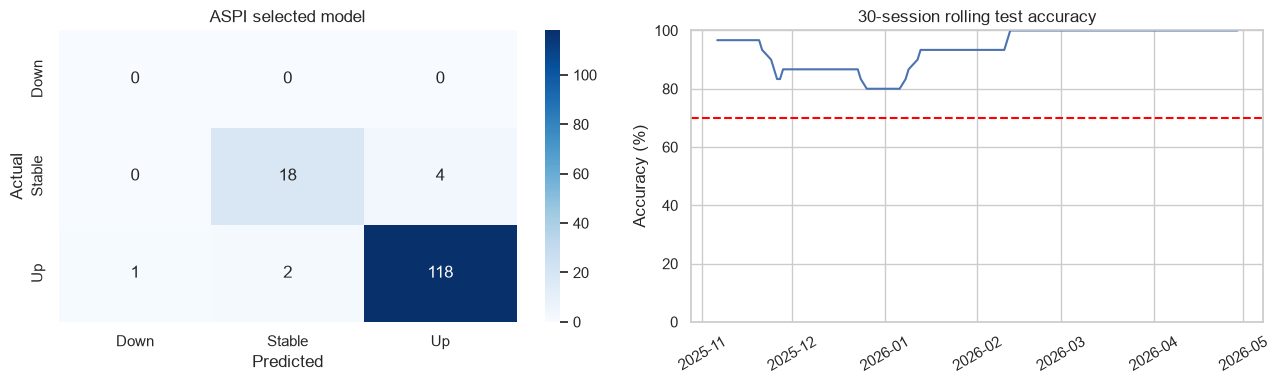

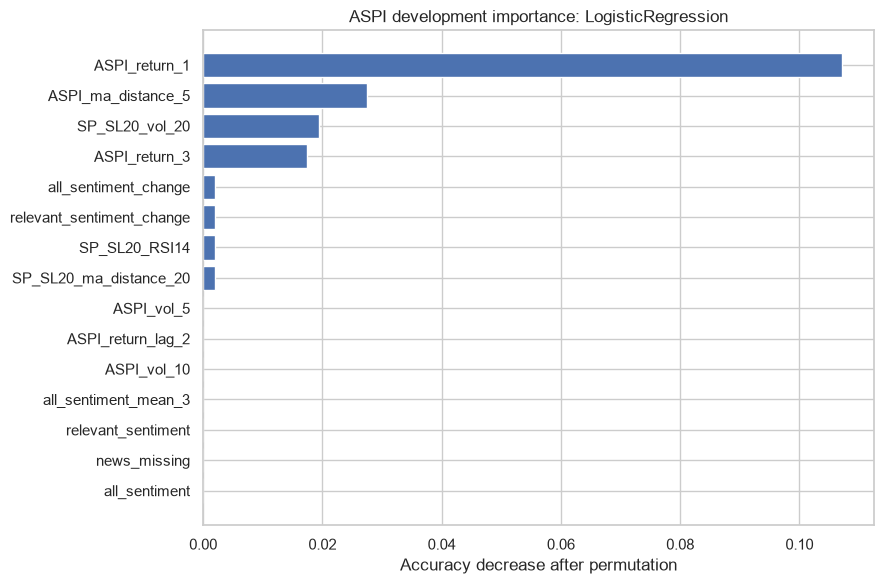

SP_SL20 ('SP_SL20', 'market', 'ExtraTrees') Accuracy: 93.01 % Approx. 95% interval: [87.41 97.9 ]
              precision    recall  f1-score   support

        Down       0.92      0.92      0.92        53
      Stable       0.90      0.90      0.90        21
          Up       0.94      0.94      0.94        69

    accuracy                           0.93       143
   macro avg       0.92      0.92      0.92       143
weighted avg       0.93      0.93      0.93       143



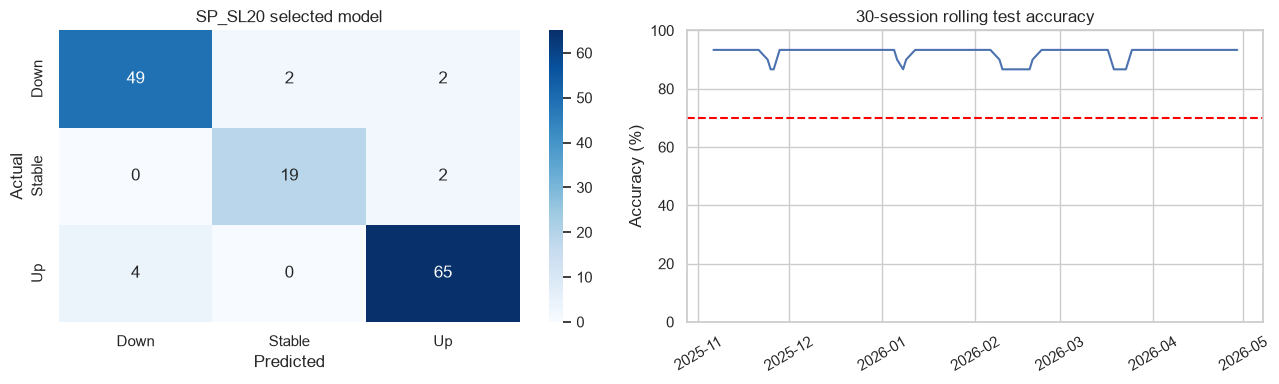

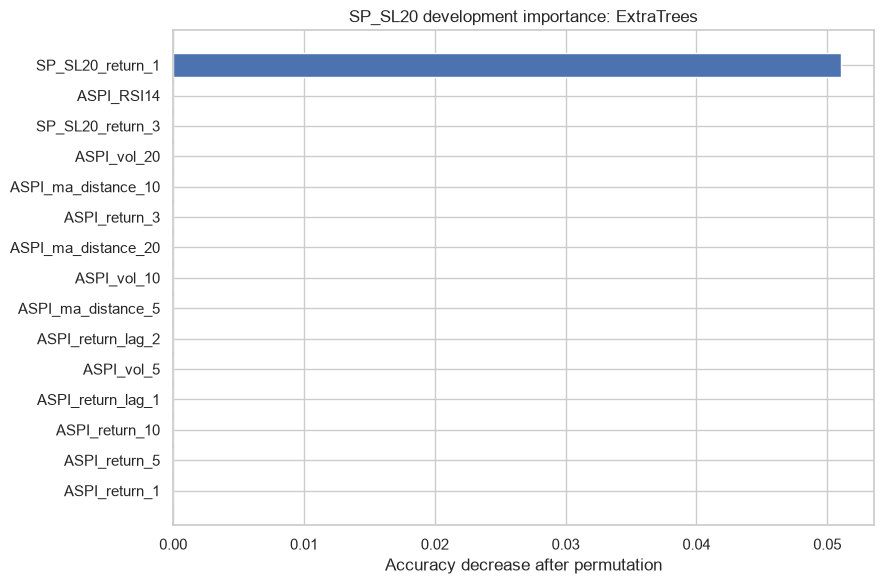

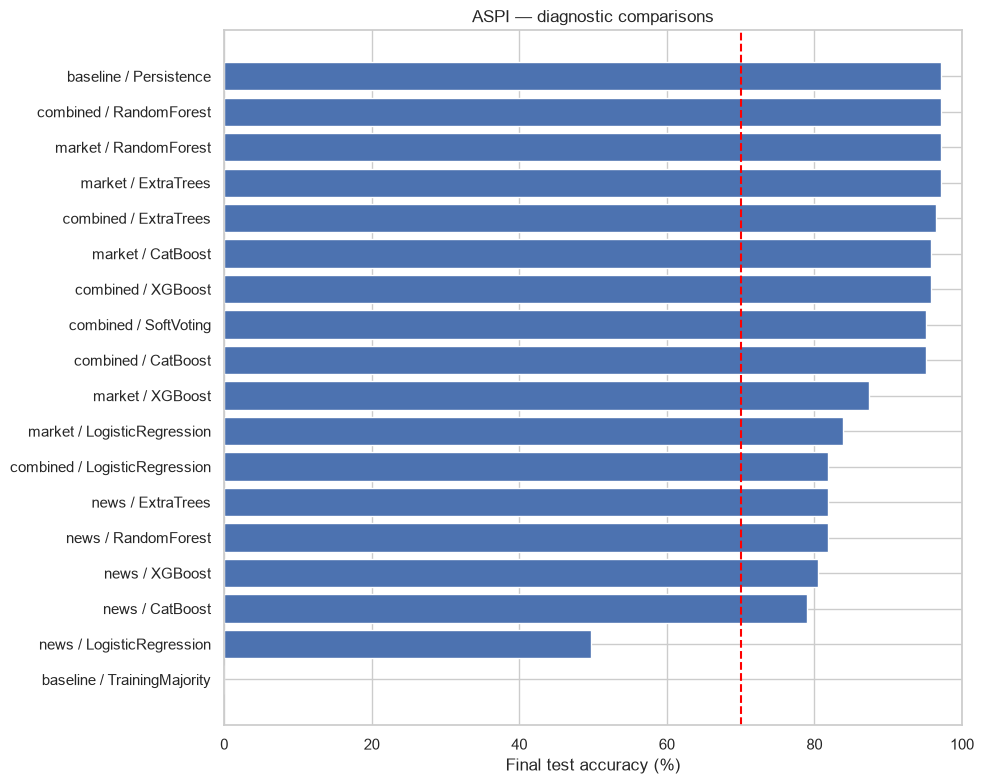

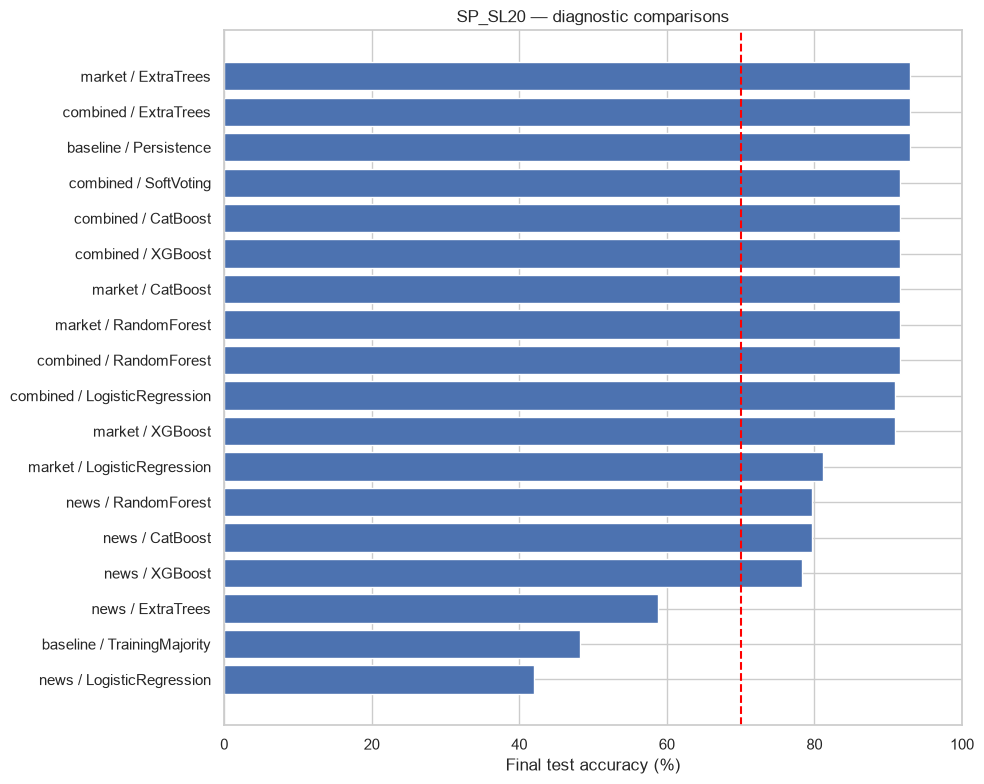

In [30]:
def block_interval(correct, block=5, repetitions=2000):
    rng=np.random.default_rng(SEED); a=np.asarray(correct,dtype=float); n=len(a)
    scores=[]
    for _ in range(repetitions):
        starts=rng.integers(0,n,size=int(np.ceil(n/block)))
        ids=np.concatenate([(start+np.arange(block))%n for start in starts])[:n]
        scores.append(a[ids].mean())
    return np.quantile(scores,[0.025,0.975])

uncertainty=[]
for index,key in selections.items():
    y=meta[index+"_y"].iloc[test_idx].astype(int).to_numpy(); pred=test_predictions[key]
    lo,hi=block_interval(y==pred)
    uncertainty.append({"index":index,"model":key[2],"accuracy":accuracy_score(y,pred),"approx_block_bootstrap_low":lo,"approx_block_bootstrap_high":hi,"block_sessions":5})
    print(index,key,"Accuracy:",round(accuracy_score(y,pred)*100,2),"%", "Approx. 95% interval:",np.round([lo*100,hi*100],2))
    print(classification_report(y,pred,labels=[0,1,2],target_names=LABELS,zero_division=0))
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    sns.heatmap(confusion_matrix(y,pred,labels=[0,1,2]),annot=True,fmt="d",xticklabels=LABELS,yticklabels=LABELS,ax=axes[0],cmap="Blues")
    axes[0].set(xlabel="Predicted",ylabel="Actual",title=index+" selected model")
    rolling=pd.Series(y==pred,dtype=float).rolling(30,min_periods=30).mean()
    axes[1].plot(meta.Trading_Date.iloc[test_idx],rolling*100)
    axes[1].axhline(70,color="red",ls="--"); axes[1].set(title="30-session rolling test accuracy",ylabel="Accuracy (%)",ylim=(0,100))
    axes[1].tick_params(axis="x",rotation=30)
    fig.tight_layout();fig.savefig(RUN_DIR/f"{index}_selected_diagnostics.png",dpi=160);plt.show()
    # Explain the selected individual model or the strongest ensemble member.
    explain_key=ensembles[index][0] if key[2]=="SoftVoting" else key
    tr,va=cv[-1]; cols=feature_sets[explain_key[1]]
    explain_model=clone(fitted[explain_key]).fit(X.iloc[train_idx[tr]][cols],meta[index+"_y"].iloc[train_idx[tr]].astype(int))
    importance=permutation_importance(explain_model,X.iloc[train_idx[va]][cols],meta[index+"_y"].iloc[train_idx[va]].astype(int),scoring="accuracy",n_repeats=10,random_state=SEED,n_jobs=1)
    imp=pd.DataFrame({"feature":cols,"mean_accuracy_drop":importance.importances_mean,"std":importance.importances_std}).sort_values("mean_accuracy_drop",ascending=False)
    imp.to_csv(RUN_DIR/f"{index}_development_permutation_importance.csv",index=False)
    fig,ax=plt.subplots(figsize=(9,6)); top=imp.head(15).sort_values("mean_accuracy_drop")
    ax.barh(top.feature,top.mean_accuracy_drop);ax.set_title(index+" development importance: "+explain_key[2]);ax.set_xlabel("Accuracy decrease after permutation")
    fig.tight_layout();fig.savefig(RUN_DIR/f"{index}_feature_importance.png",dpi=160);plt.show()
pd.DataFrame(uncertainty).to_csv(RUN_DIR/"selected_accuracy_intervals.csv",index=False)
for index in ["ASPI","SP_SL20"]:
    sub=results[results["index"].eq(index)].copy();sub["label"]=sub.features+" / "+sub.model
    fig,ax=plt.subplots(figsize=(10,8));sub=sub.sort_values("accuracy")
    ax.barh(sub.label,sub.accuracy*100);ax.axvline(70,color="red",ls="--");ax.set(xlabel="Final test accuracy (%)",title=index+" — diagnostic comparisons",xlim=(0,100))
    fig.tight_layout();fig.savefig(RUN_DIR/f"{index}_all_accuracies.png",dpi=160);plt.show()


## 11. Save fitted models and a latest historical forecast
The latest workbook row is historical, not today. The forecast below is for its next actual trading session; no future session date is invented. Deployment copies are refitted using all labels known strictly before that row, after final-test reporting. Their training accuracy is not another test result. Model bundles require the same feature-generation code and package versions. Never load untrusted joblib files.

In [31]:
latest_row=len(df)-1
latest_features=features.iloc[[latest_row]]
latest_forecasts=[]
for index,key in selections.items():
    members=ensembles[index] if key[2]=="SoftVoting" else [key]
    known=(df.index>=21+FEATURE_DELAY)&df[index+"_y"].notna()&(df.Target_Date < df.Trading_Date.iloc[-1])
    deploy=[]; probabilities=[]
    for member in members:
        cols=feature_sets[member[1]]
        m=clone(fitted[member]).fit(features.loc[known,cols],df.loc[known,index+"_y"].astype(int))
        deploy.append({"key":member,"columns":cols,"model":m})
        probabilities.append(aligned_proba(m,latest_features[cols]))
    p=np.mean(probabilities,axis=0)[0]
    latest_forecasts.append({"index":index,"as_of_historical_date":str(df.Trading_Date.iloc[-1].date()),"horizon":"next actual trading session","prediction":LABELS[int(p.argmax())],**{f"prob_{label}":float(p[j]) for j,label in enumerate(LABELS)}})
    joblib.dump({"members":deploy,"aggregation":"equal_probability_mean","labels":LABELS,"manifest":manifest},RUN_DIR/f"{index}_deployment_bundle.joblib")
    # Preserve frozen pre-test models too for exact reproducibility of test results.
    joblib.dump({"members":[{"key":m,"columns":feature_sets[m[1]],"model":fitted[m]} for m in members],"manifest":manifest},RUN_DIR/f"{index}_evaluation_bundle.joblib")
latest=pd.DataFrame(latest_forecasts); latest.to_csv(RUN_DIR/"latest_HISTORICAL_forecast.csv",index=False)
display(latest)
summary=["ASPI / S&P SL20 research run", "", "Primary results: pre-test selected models", selected_results.to_string(index=False), "", "Accuracy uncertainty",pd.DataFrame(uncertainty).to_string(index=False),"", "Limitations: article timestamps and market source availability are unverified. One-session feature delay does not prove historical availability. Headline relevance uses a heuristic. No live trading or profit claims. Do not retune using this final test."]
(RUN_DIR/"RESULTS_SUMMARY.txt").write_text("\n".join(summary),encoding="utf-8")
print("Complete. All outputs saved to:",RUN_DIR)
print("Main files: FINAL_SELECTED_RESULTS.csv, ALL_TEST_ACCURACIES.csv, RESULTS_SUMMARY.txt")


,index,as_of_historical_date,horizon,prediction,prob_Down,prob_Stable,prob_Up
0,ASPI,2026-04-30,next actual trading session,Up,0.021565,0.050980,0.927454
1,SP_SL20,2026-04-30,next actual trading session,Up,0.030480,0.054789,0.914730


Complete. All outputs saved to: C:\Users\USER\OneDrive\Documents\RESEARCH METHODOLOGY\FINALS\2026 OCT 01\CSE_Research_Outputs\run_20261002_101508_699854
Main files: FINAL_SELECTED_RESULTS.csv, ALL_TEST_ACCURACIES.csv, RESULTS_SUMMARY.txt


## Reading your results
- **FINAL_SELECTED_RESULTS.csv:** primary held-out results for the models selected before testing. `above_70_percent` is true only when accuracy is strictly greater than 70%.
- **ALL_TEST_ACCURACIES.csv:** every individual model/feature combination, baselines and voting. Do not pick a new winner from this table and call it independently validated.
- **validation_model_comparison.csv:** development tuning results, including training accuracy and fold variability.
- **predictions_*.csv / report_*.csv:** dates, actual/predicted labels, probabilities, and class precision/recall/F1.
- **headline_sentiment.csv / daily_features_and_targets.csv:** reproducible features and sentiment outputs.
- **PNG files:** histories, confusion matrices, rolling accuracy, model comparisons and development feature importance.
- **frozen_experiment_manifest.json:** split, parameters, versions, source hash, resolved FinBERT revision and timing assumption.

If accuracy is below 70%, report that result. Investigate data quality, relevance and additional historical information using development data. A new iteration after inspecting this holdout needs new future observations for a fresh independent test. Excluding difficult test days or changing thresholds to improve the reported score changes the experiment.

### References
- [FinBERT model card](https://huggingface.co/ProsusAI/finbert)
- [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)
- [Scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html)
- [XGBoost parameters](https://xgboost.readthedocs.io/en/stable/parameter.html)
- [CatBoost tuning](https://catboost.ai/docs/en/concepts/parameter-tuning)
